# run_classical_experiments.py

In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 5.9 MB/s eta 0:00:00


In [ ]:
# run_classical_experiments.py
# Полный эксперимент для классических алгоритмов (жадный, 2-OPT, Tabu Search, ГА, точное решение)
# на предобработанных данных для 12 и 29 складов.
# Сохраняет результаты, строит графики, валидирует маршруты по графу и визуализирует лучшие из них.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import osmnx as ox
import zipfile

from utils import (
    INF, calculate_route_distance, zip_folder, unzip_all,
    validate_route_on_graph, plot_route_on_map
)
from classical import greedy_tsp, tsp_2opt, tabu_search_tsp, genetic_algorithm_tsp, exact_atsp
from preprocess import load_preprocessed_matrices, load_warehouse_info

In [ ]:
# Конфигурация
SCENARIO_NAMES = ['Без_шума', 'Пробки', 'Блокировки_Пробки', 'Умеренные_условия']
ALGORITHMS = {
    'Greedy': greedy_tsp,
    '2-OPT': lambda dm, s: tsp_2opt(greedy_tsp(dm, s)[0], dm)[:3],
    'Tabu Search': lambda dm, s: tabu_search_tsp(dm, s, max_iter=200, tabu_size=20),
    'Genetic': lambda dm, s: genetic_algorithm_tsp(dm, s, pop_size=30, generations=50)
}
START_IDX = 0  # Павлово-Слободское РЦ

OUTPUT_DIR = "classical_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Попытка загрузить оригинальный граф для валидации и визуализации (может отсутствовать)
GRAPH_PATH_CANDIDATES = ["raw_data/moscow_region_drive_network.graphml",
                         "moscow_region_drive_network.graphml"]
original_graph = None
for path in GRAPH_PATH_CANDIDATES:
    if os.path.exists(path):
        try:
            original_graph = ox.load_graphml(path)
            print(f"Граф загружен из {path} для визуализации и валидации.")
            break
        except Exception as e:
            print(f"Не удалось загрузить граф {path}: {e}")

In [ ]:
def ensure_data_available():
    """Распаковывает архивы raw_data.zip и preprocessed_data.zip."""
    archives = ["raw_data.zip", "preprocessed_data.zip"]
    unzip_all(archives, extract_to='.')

In [ ]:
# Функции визуализации
def validate_and_visualize_route(route, distance_matrix, warehouses_df, warehouse_nodes,
                                 scenario, algo_name, dist_km, force=False):
    if original_graph is None:
        return
    if scenario != 'Без_шума':
        # Для шумовых сценариев валидацию по графу не проводим, только визуализацию
        print(f"Визуализация маршрута на оригинальном графе (пробки/блокировки не отражены)")
        # Визуализация без валидации
        coords, graph_length, _ = validate_route_on_graph(
            original_graph, route, warehouse_nodes, distance_matrix=None, tolerance=1.0
        )
        if coords:
            title = f"{algo_name} на {scenario} ({dist_km:.2f} км) – дороги без пробок"
            fname = os.path.join(OUTPUT_DIR, f"route_{scenario.replace(' ', '_')}_{algo_name.replace(' ', '_')}.png")
            plot_route_on_map(coords, warehouses_df, route, title, fname)
        return

    # Для сценария "Без_шума" выполняем полную валидацию
    coords, graph_length, consistent = validate_route_on_graph(
        original_graph, route, warehouse_nodes, distance_matrix, tolerance=1.0
    )
    if coords:
        title = f"{algo_name} на {scenario} ({dist_km:.2f} км)"
        fname = os.path.join(OUTPUT_DIR, f"route_{scenario.replace(' ', '_')}_{algo_name.replace(' ', '_')}.png")
        plot_route_on_map(coords, warehouses_df, route, title, fname)

In [ ]:
# Запуск экспериментов для одного набора
def run_for_warehouse_set(use_all=False, run_exact_for_12=True):
    """
    Запускает все алгоритмы на всех сценариях для выбранного набора складов.
    Возвращает DataFrame с результатами и информацию о складах.
    """
    matrices = load_preprocessed_matrices(use_all=use_all)
    if not matrices:
        print(f"Матрицы для {'29' if use_all else '12'} складов не найдены. Запустите preprocess.py.")
        return None, None

    n_warehouses = next(iter(matrices.values())).shape[0]
    print(f"\nЗапуск для {n_warehouses} складов")

    # Загрузка информации о складах
    warehouses_df = None
    warehouse_nodes = None
    try:
        warehouses_df = load_warehouse_info(use_all=use_all, scenario_name='Без_шума')
        warehouse_nodes = warehouses_df['node_id'].tolist()
    except Exception as e:
        print(f"Не удалось загрузить информацию о складах: {e}")

    results = []
    for scenario, dm in matrices.items():
        print(f"\n  Сценарий: {scenario} (n={dm.shape[0]})")
        for algo_name, algo_func in ALGORITHMS.items():
            start_t = time.time()
            try:
                route, dist_m, _ = algo_func(dm, START_IDX)
                elapsed = time.time() - start_t
                dist_km = dist_m / 1000.0
                results.append({
                    'warehouse_set': '29' if use_all else '12',
                    'scenario': scenario,
                    'algorithm': algo_name,
                    'distance_km': dist_km,
                    'time_sec': elapsed,
                    'n_warehouses': dm.shape[0]
                })
                print(f"  {algo_name:12} : {dist_km:7.2f} км, {elapsed:6.3f} сек")
                # Валидация и визуализация
                if warehouses_df is not None and warehouse_nodes is not None:
                    validate_and_visualize_route(route, dm, warehouses_df, warehouse_nodes,
                                                 scenario, algo_name, dist_km)
            except Exception as e:
                print(f"  {algo_name:12} : ошибка: {e}")

        # Точное решение ATSP (Held-Karp) для сценария "Без_шума" (любой размерности)
        if run_exact_for_12 and dm.shape[0] <= 20:   # флаг run_exact_for_12 теперь управляет запуском exact
            print(f"  Вычисление точного решения ATSP (Held-Karp) для n={dm.shape[0]}")
            try:
                opt_route, opt_dist_m, opt_time = exact_atsp(dm, START_IDX)
                opt_dist_km = opt_dist_m / 1000.0
                results.append({
                    'warehouse_set': '29' if use_all else '12',
                    'scenario': scenario,
                    'algorithm': 'OPTIMUM (Exact)',
                    'distance_km': opt_dist_km,
                    'time_sec': opt_time,
                    'n_warehouses': dm.shape[0]
                })
                print(f"  {'OPTIMUM':12} : {opt_dist_km:7.2f} км, {opt_time:6.3f} сек")
                if warehouses_df is not None and warehouse_nodes is not None:
                    validate_and_visualize_route(opt_route, dm, warehouses_df, warehouse_nodes,
                                                 scenario, 'OPTIMUM (Exact)', opt_dist_km, force=True)
            except Exception as e:
                print(f"  Ошибка точного решения: {e}")

    return pd.DataFrame(results), warehouses_df

In [ ]:
# Графики
def plot_comparison(df, title_prefix, filename):
    """
    Строит четыре графика:
    1. Длина маршрута по сценариям (группированные столбцы)
    2. Среднее время выполнения алгоритмов
    3. Увеличение расстояния относительно базового сценария (%)
    4. Коэффициент вариации длины (стабильность)
    """
    if df.empty:
        return
    scenarios = df['scenario'].unique()
    algorithms = df['algorithm'].unique()
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    ax1, ax2, ax3, ax4 = axes.flatten()

    # 1. Расстояние по сценариям
    x = np.arange(len(scenarios))
    width = 0.2
    sorted_algs = sorted(algorithms, key=lambda a: (a == 'OPTIMUM (Exact)', a))
    for i, algo in enumerate(sorted_algs):
        vals = []
        for s in scenarios:
            sub = df[(df['algorithm'] == algo) & (df['scenario'] == s)]
            vals.append(sub['distance_km'].values[0] if not sub.empty else np.nan)
        ax1.bar(x + i*width, vals, width, label=algo, alpha=0.8)
    ax1.set_xticks(x + width*(len(sorted_algs)-1)/2)
    ax1.set_xticklabels(scenarios, rotation=45)
    ax1.set_ylabel('Расстояние (км)')
    ax1.set_title('Длина маршрута по сценариям')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Среднее время выполнения
    times = df[~df['algorithm'].str.contains('OPTIMUM')].groupby('algorithm')['time_sec'].mean()
    ax2.bar(times.index, times.values, color='lightcoral')
    ax2.set_ylabel('Среднее время (сек)')
    ax2.set_title('Время выполнения')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)

    # 3. Увеличение расстояния относительно базового сценария
    base_scenario = scenarios[0]
    base = df[df['scenario'] == base_scenario]
    inc_data = []
    for s in scenarios[1:]:
        cur = df[df['scenario'] == s]
        for algo in algorithms:
            base_val = base[base['algorithm'] == algo]['distance_km'].values
            cur_val = cur[cur['algorithm'] == algo]['distance_km'].values
            if len(base_val) > 0 and len(cur_val) > 0:
                inc = (cur_val[0] - base_val[0]) / base_val[0] * 100
                inc_data.append({'scenario': s, 'algorithm': algo, 'increase': inc})
    inc_df = pd.DataFrame(inc_data)
    for i, algo in enumerate(sorted_algs):
        vals = []
        for s in scenarios[1:]:
            sub = inc_df[(inc_df['algorithm'] == algo) & (inc_df['scenario'] == s)]
            vals.append(sub['increase'].values[0] if not sub.empty else 0)
        ax3.bar(x[1:] + i*width, vals, width, label=algo, alpha=0.8)
    ax3.set_xticks(x[1:] + width*(len(sorted_algs)-1)/2)
    ax3.set_xticklabels(scenarios[1:], rotation=45)
    ax3.set_ylabel('Увеличение (%)')
    ax3.set_title('Ухудшение относительно базового сценария')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    # 4. Коэффициент вариации (стабильность)
    cv = []
    alg_names = []
    for algo in algorithms:
        if algo == 'OPTIMUM (Exact)':
            continue
        d = df[df['algorithm'] == algo]['distance_km']
        if len(d) > 0:
            cv.append(d.std() / d.mean() * 100 if d.mean() > 0 else 0)
            alg_names.append(algo)
    ax4.bar(alg_names, cv, color='lightgreen')
    ax4.set_ylabel('Коэффициент вариации (%)')
    ax4.set_title('Стабильность (меньше = лучше)')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3)

    plt.suptitle(f'Сравнение алгоритмов — {title_prefix}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(filename, dpi=200)
    plt.show()
    print(f"График сохранён: {filename}")

In [ ]:
# Точка входа
def main():
    ensure_data_available()

    # 12 складов
    df12, _ = run_for_warehouse_set(use_all=False, run_exact_for_12=True)
    if df12 is not None:
        df12.to_csv(os.path.join(OUTPUT_DIR, "results_12.csv"), index=False)
        plot_comparison(df12, "12 складов (РЦ/РФЦ)",
                        os.path.join(OUTPUT_DIR, "comparison_12.png"))

    # 29 складов (точное решение не запускаем)
    df29, _ = run_for_warehouse_set(use_all=True, run_exact_for_12=False)
    if df29 is not None:
        df29.to_csv(os.path.join(OUTPUT_DIR, "results_29.csv"), index=False)
        plot_comparison(df29, "29 складов (все)",
                        os.path.join(OUTPUT_DIR, "comparison_29.png"))

    # Объединённая таблица
    if df12 is not None and df29 is not None:
        combined = pd.concat([df12, df29], ignore_index=True)
        combined.to_csv(os.path.join(OUTPUT_DIR, "results_all.csv"), index=False)
        print("\nРезультаты сохранены в папке 'classical_results'.")

    # Архивация
    if 'zip_folder' in globals():
        zip_path = zip_folder(OUTPUT_DIR)
        print(f"Архив создан: {zip_path}")
    else:
        print("Функция zip_folder не найдена, архивируйте папку вручную.")

Распаковываем raw_data.zip в .
Распакован: raw_data.zip
Распаковываем preprocessed_data.zip в .
Распакован: preprocessed_data.zip

Запуск для 12 складов

  Сценарий: Без_шума (n=12)
  Greedy       :  406.84 км,  0.000 сек
  2-OPT        :  406.84 км,  0.000 сек
  Tabu Search  :  406.34 км,  0.091 сек
  Genetic      :  530.99 км,  0.028 сек
  Вычисление точного решения ATSP (Held-Karp) для n=12
  OPTIMUM      :  406.34 км,  0.095 сек

  Сценарий: Пробки (n=12)
  Greedy       :  510.55 км,  0.000 сек
  2-OPT        :  510.55 км,  0.000 сек
  Tabu Search  :  456.33 км,  0.094 сек
  Genetic      :  525.61 км,  0.043 сек
  Вычисление точного решения ATSP (Held-Karp) для n=12
  OPTIMUM      :  456.33 км,  0.097 сек

  Сценарий: Блокировки_Пробки (n=12)
  Greedy       :  473.43 км,  0.000 сек
  2-OPT        :  459.54 км,  0.000 сек
  Tabu Search  :  444.14 км,  0.094 сек
  Genetic      :  551.14 км,  0.022 сек
  Вычисление точного решения ATSP (Held-Karp) для n=12
  OPTIMUM      :  444.14 км,

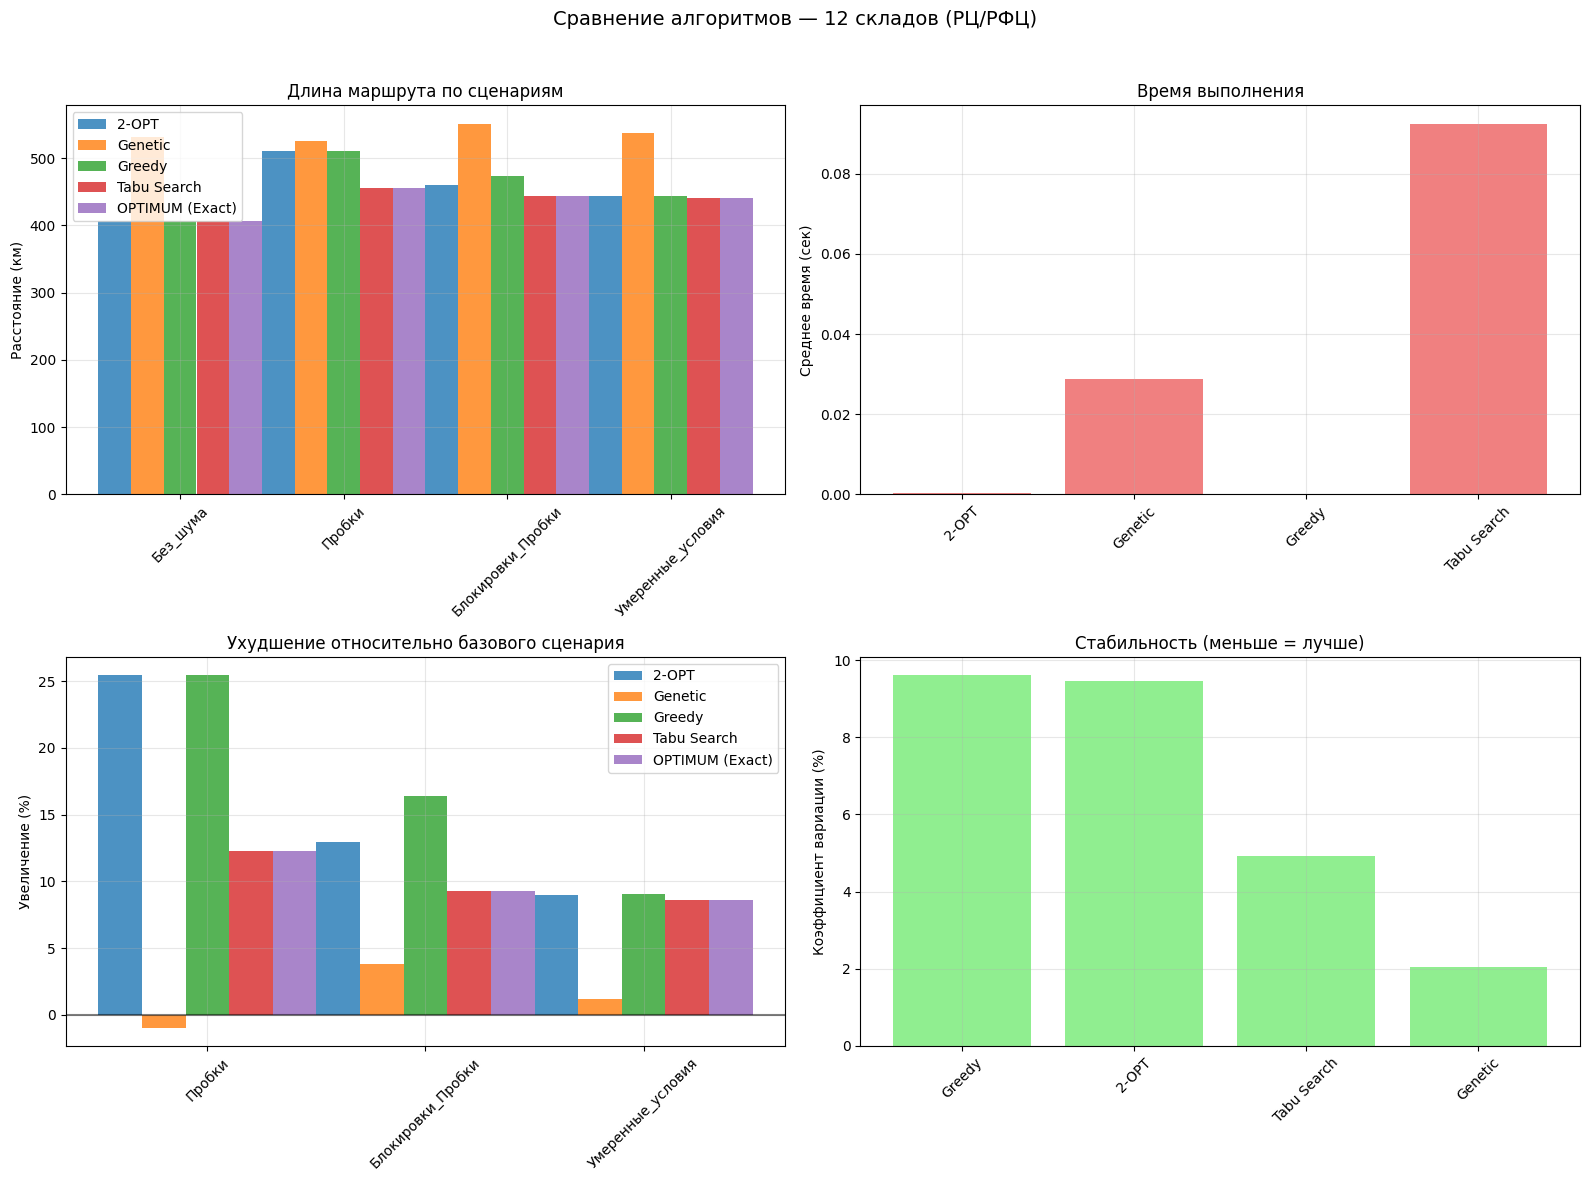

График сохранён: classical_results/comparison_12.png

Запуск для 29 складов

  Сценарий: Без_шума (n=29)
  Greedy       :  712.65 км,  0.000 сек
  2-OPT        :  635.97 км,  0.050 сек
  Tabu Search  :  657.18 км,  0.380 сек
  Genetic      :  991.07 км,  0.084 сек

  Сценарий: Пробки (n=29)
  Greedy       :  807.89 км,  0.000 сек
  2-OPT        :  769.76 км,  0.019 сек
  Tabu Search  :  726.00 км,  0.361 сек
  Genetic      : 1225.38 км,  0.085 сек

  Сценарий: Блокировки_Пробки (n=29)
  Greedy       :  769.78 км,  0.000 сек
  2-OPT        :  769.78 км,  0.009 сек
  Tabu Search  :  739.53 км,  0.390 сек
  Genetic      : 1137.09 км,  0.079 сек

  Сценарий: Умеренные_условия (n=29)
  Greedy       :  773.57 км,  0.000 сек
  2-OPT        :  699.21 км,  0.013 сек
  Tabu Search  :  710.58 км,  0.359 сек
  Genetic      : 1248.27 км,  0.078 сек


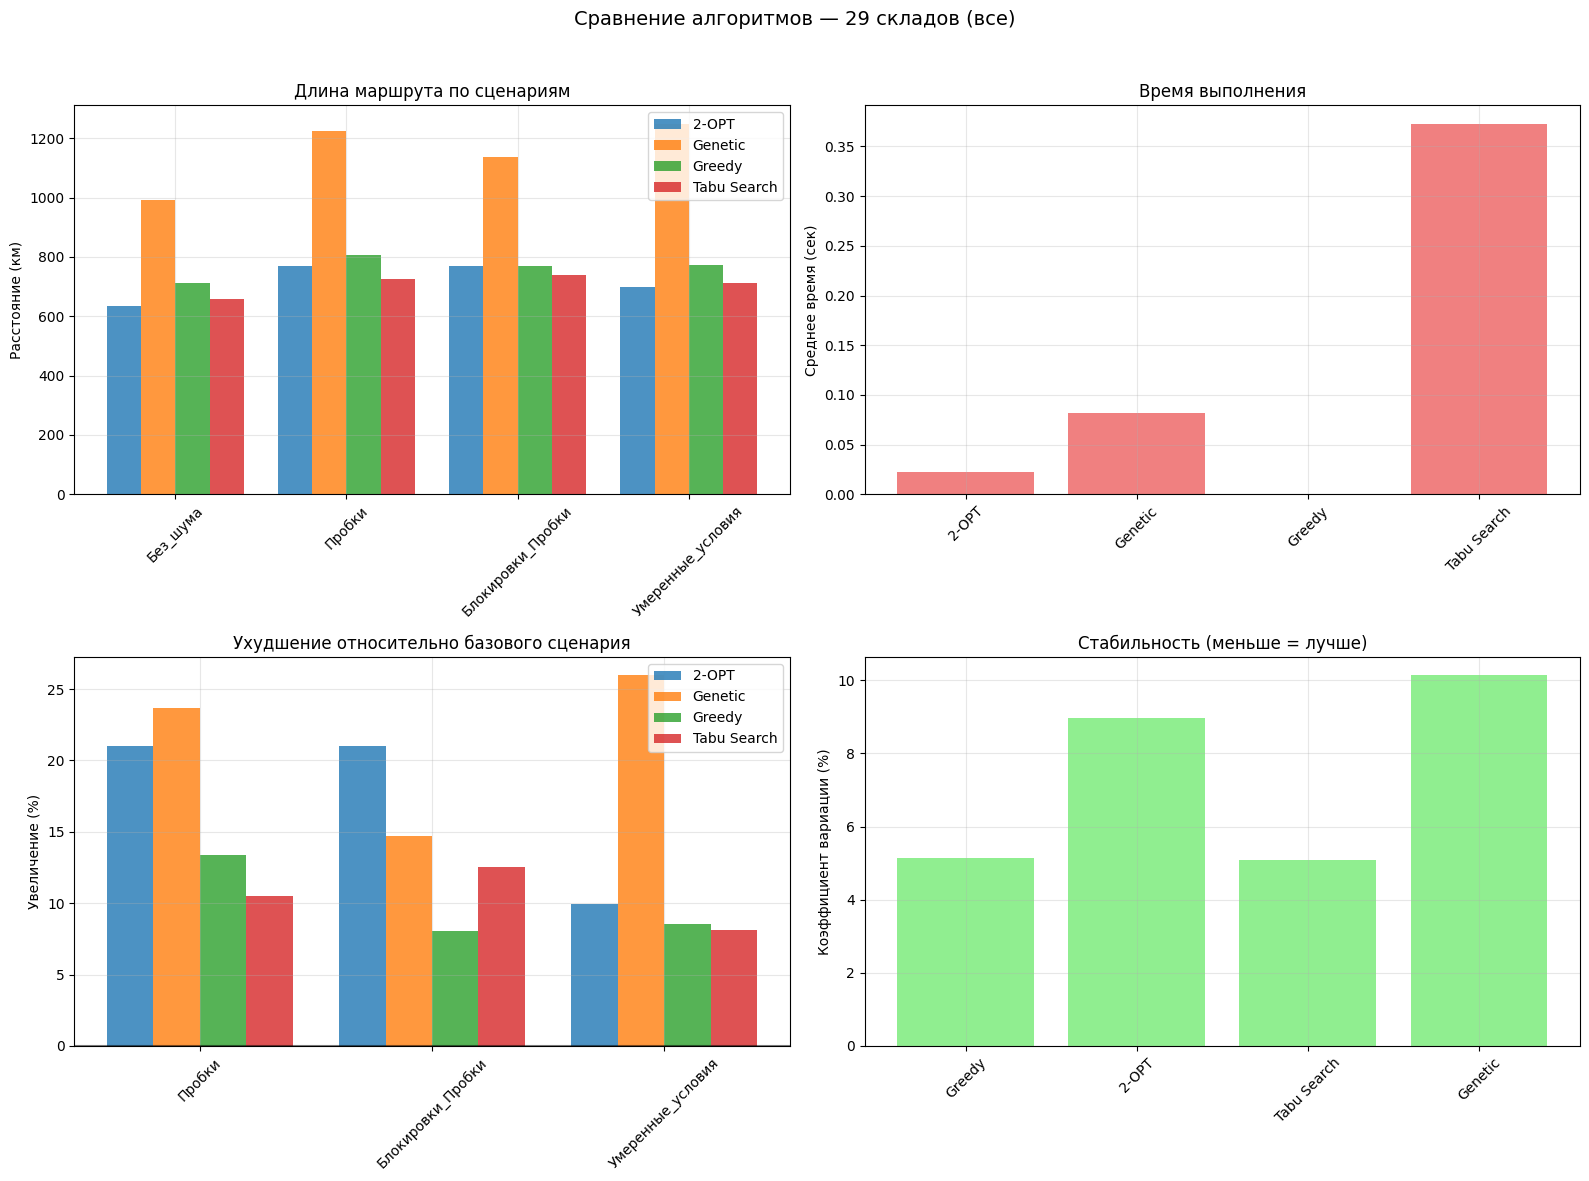

График сохранён: classical_results/comparison_29.png

Результаты сохранены в папке 'classical_results'.
Папка classical_results заархивирована в classical_results.zip
Архив создан: classical_results.zip


In [ ]:
if __name__ == "__main__":
    main()